# 6 — Benchmark SegFormer (MiT-B0)

|                |                                    |
| -------------- | ---------------------------------- |
| **Modèle**     | SegFormer avec encodeur MiT-B0     |
| **Framework**  | TensorFlow / Keras via `keras-hub` |
| **Résolution** | 256 × 256                          |
| **Loss**       | CE + 0.5 × Dice                    |
| **Métrique**   | mIoU (classes 0-7, IGNORE=255)     |

SegFormer (Xie et al., NeurIPS 2021) est une architecture **pure Transformer** pour la segmentation sémantique.

Architecture en deux parties :

- **Encodeur Mix Transformer (MiT)** : blocs d'attention locale avec patches chevauchants sur 4 échelles.
  MiT-B0 (~3.8M params) est la variante la plus légère
- **Tête MLP All-MLP** : fusionne les features multi-échelles par de simples couches linéaires.

**Références** :

- Xie et al., _SegFormer: Simple and Efficient Design for Semantic Segmentation_, NeurIPS 2021
  https://arxiv.org/abs/2105.15203
- keras-hub `SegFormerBackbone` + `SegFormerImageSegmenter`


In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")


ROOT = /home/ui/PROJ9


In [2]:
import os, gc, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras import backend as K

try:
    import keras_hub
    print(f"keras_hub {keras_hub.__version__} OK")
except ImportError:
    raise ImportError(
        "keras_hub manquant. Installe : pip install keras-hub  puis relance le kernel."
    )

from scripts.config import ensure_dirs, resolve_split_csv, CITYSCAPES_DIR, EXP_DIR
from scripts.preprocessing import (
    load_rgb, load_mask_labelids, remap_to_groups, colorize_groups,
    CATEGORY_NAMES, IGNORE_LABEL, N_CLASSES, PALETTE
)
from scripts.datagen import CityscapesSequence
from scripts.augmentations import make_train_aug
from scripts.losses_metrics import MeanIoUArgmax, dice_loss_sparse
from scripts.models import segformer_mitb0, SegFormerPreprocess

ensure_dirs()
print("TF :", tf.__version__)
print("GPU :", [g.name for g in tf.config.list_physical_devices("GPU")])


2026-02-26 11:42:10.943545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


keras_hub 0.26.0 OK
TF : 2.20.0
GPU : ['/physical_device:GPU:0']


I0000 00:00:1772102537.565425 4123114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4414 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


## Configuration :


In [ ]:
SIZE_HW           = (256, 256)
BATCH             = 4
EPOCHS            = 50
PATIENCE          = 10
AUG               = True
AUG_REPEATS       = 1
LR                = 5e-4
ENCODER_PRESET    = "mit_b0_cityscapes_1024"
ENCODER_TRAINABLE = False

EPOCHS_FT         = 30
LR_FT             = 5e-5
PATIENCE_FT       = 10
SEED              = 42

OUT_DIR = EXP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"SEGFORMER_MITB0_{SIZE_HW[0]}x{SIZE_HW[1]}"
    f"_b{BATCH}_aug{int(AUG)}_rep{AUG_REPEATS}_ce_dice"
    f"_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}"
)
BEST_PATH    = OUT_DIR / f"{RUN_NAME}.keras"
RESULTS_JSON = OUT_DIR / f"{RUN_NAME}_results.json"
print("Run :", RUN_NAME)


Run : SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42


## Données :


In [4]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

df       = pd.read_csv(resolve_split_csv())
train_df = df[df["split_final"] == "train"].copy()
val_df   = df[df["split_final"] == "val"].copy()
test_df  = df[df["split_final"] == "test"].copy()
print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

train_aug = make_train_aug() if AUG else None
train_seq = CityscapesSequence(train_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=train_aug, shuffle=True, seed=SEED, aug_repeats=AUG_REPEATS)
val_seq   = CityscapesSequence(val_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)
test_seq  = CityscapesSequence(test_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)
print(f"Étapes — train: {len(train_seq)} | val: {len(val_seq)} | test: {len(test_seq)}")


Train : 2380  |  Val : 500  |  Test : 595
Étapes — train: 595 | val: 125 | test: 149


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env0/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Modèle SegFormer :

- Encodeur MiT-B0 **gelé** en phase 1, **dégelé** en phase 2.
- La tête MLP-Decoder est toujours entraînable.


In [5]:
K.clear_session(); gc.collect()
model = segformer_mitb0(
    input_shape=(SIZE_HW[0], SIZE_HW[1], 3),
    n_classes=N_CLASSES,
    encoder_preset=ENCODER_PRESET,
    trainable=ENCODER_TRAINABLE,
    projection_filters=256,
)
model.summary(line_length=100, expand_nested=False)
n_train = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\nParams entraînables : {n_train:,}")


Model: "segformer_mitb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_rgb_01 (InputLayer)                  │ (None, 256, 256, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ segformer_preprocess (SegFormerPreprocess) │ (None, 256, 256, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ seg_former_image_segmenter                 │ (None, 256, 256, 8)             │         3,716,712 │
│ (SegFormerImageSegmenter)                  │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ probs (Softmax)                            │ (None, 256, 256, 8)             │                 0 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 3,716,712 (14.18 MB)

 Trainable params: 396,808 (1.51 MB)

 Non-trainable params: 3,319,904 (12.66 MB)


Params entraînables : 396,808


In [6]:
def compile_model(m, lr):
    def loss_fn(y_true, y_pred):
        y_t   = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        valid  = tf.not_equal(y_t, IGNORE_LABEL)
        y_s   = tf.where(valid, y_t, tf.zeros_like(y_t))
        ce    = tf.keras.losses.sparse_categorical_crossentropy(y_s, y_pred)
        ce    = tf.where(valid, ce, 0.0)
        denom = tf.reduce_sum(tf.cast(valid, tf.float32)) + 1e-6
        return tf.reduce_sum(ce)/denom + 0.5*dice_loss_sparse(y_true, y_pred, n_classes=N_CLASSES)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[MeanIoUArgmax(num_classes=N_CLASSES, name="mIoU")],
    )
    return m


## Phase 1 — Tête MLP seulement


In [7]:
model = compile_model(model, lr=LR)
cb1 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                 factor=0.5, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase1.csv")),
]
t0    = time.time()
hist1 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS, callbacks=cb1, verbose=1)
t_ph1 = time.time() - t0
print(f"\nPhase 1 : {t_ph1/60:.1f} min")


Epoch 1/50


2026-02-26 11:42:33.187273: I external/local_xla/xla/service/service.cc:163] XLA service 0x786a58010a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-26 11:42:33.187304: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2026-02-26 11:42:33.582980: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-26 11:42:36.997494: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-02-26 11:42:37.887073: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-26 11:42:57.984571: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local mem

595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 0.8843 - mIoU: 0.4915

2026-02-26 11:46:07.909079: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_mIoU improved from None to 0.64670, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 269s 390ms/step - loss: 0.7454 - mIoU: 0.5455 - val_loss: 0.5248 - val_mIoU: 0.6467 - learning_rate: 5.0000e-04
Epoch 2/50
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.6469 - mIoU: 0.5877
Epoch 2: val_mIoU improved from 0.64670 to 0.65518, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 205s 345ms/step - loss: 0.6453 - mIoU: 0.5886 - val_loss: 0.5076 - val_mIoU: 0.6552 - learning_rate: 5.0000e-04
Epoch 3/50
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s

## Phase 2 — Fine-tuning (MiT dégelé)


In [8]:
custom_objs = {"MeanIoUArgmax": MeanIoUArgmax, "dice_loss_sparse": dice_loss_sparse,
               "SegFormerPreprocess": SegFormerPreprocess}
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)
for layer in model.layers:
    layer.trainable = True
model = compile_model(model, lr=LR_FT)

cb2 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE_FT,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                 factor=0.5, min_lr=1e-7, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase2.csv")),
]
t0    = time.time()
hist2 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS_FT, callbacks=cb2, verbose=1)
t_ph2 = time.time() - t0
t_tot = t_ph1 + t_ph2
print(f"\nPhase 2 : {t_ph2/60:.1f} min  |  Total : {t_tot/60:.1f} min")


/home/ui/PROJ9/.env0/lib/python3.12/site-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Epoch 1/30


2026-02-26 14:33:30.985894: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-02-26 14:34:07.688498: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_1', 44 bytes spill stores, 28 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_3', 16 bytes spill stores, 16 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_4', 28 bytes spill stores, 28 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_7', 116 bytes spill stores, 116 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_6', 112 

595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - loss: 0.5291 - mIoU: 0.6415

2026-02-26 14:37:02.704738: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_mIoU improved from None to 0.69208, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 285s 358ms/step - loss: 0.5224 - mIoU: 0.6452 - val_loss: 0.4412 - val_mIoU: 0.6921 - learning_rate: 5.0000e-05
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 0.4977 - mIoU: 0.6577
Epoch 2: val_mIoU improved from 0.69208 to 0.69404, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 202s 339ms/step - loss: 0.4917 - mIoU: 0.6612 - val_loss: 0.4338 - val_mIoU: 0.6940 - learning_rate: 5.0000e-05
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s

## Évaluation finale :


In [9]:
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)
model = compile_model(model, lr=LR_FT)
val_res  = model.evaluate(val_seq,  verbose=1)
test_res = model.evaluate(test_seq, verbose=1)
print(f"\nVal  — Loss: {val_res[0]:.4f}  mIoU: {val_res[1]:.4f}")
print(f"Test — Loss: {test_res[0]:.4f}  mIoU: {test_res[1]:.4f}")


2026-02-26 16:15:15.465780: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 275ms/step - loss: 0.4015 - mIoU: 0.7140
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.3742 - mIoU: 0.7246

2026-02-26 16:16:47.554940: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


149/149 ━━━━━━━━━━━━━━━━━━━━ 57s 383ms/step - loss: 0.3620 - mIoU: 0.7305

Val  — Loss: 0.4015  mIoU: 0.7140
Test — Loss: 0.3620  mIoU: 0.7305


In [10]:
from sklearn.metrics import confusion_matrix

def compute_per_class_iou(model, seq, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    conf = np.zeros((n_classes, n_classes), dtype=np.int64)
    for X, y in seq:
        preds = np.argmax(model.predict(X, verbose=0), axis=-1)
        gt    = y[..., 0].astype(np.int32)
        valid = gt != ignore
        conf += confusion_matrix(gt[valid].flatten(), preds[valid].flatten(),
                                  labels=list(range(n_classes)))
    iou = []
    for c in range(n_classes):
        tp = conf[c,c]; fn = conf[c,:].sum()-tp; fp = conf[:,c].sum()-tp
        denom = tp+fn+fp
        iou.append(float(tp)/float(denom) if denom > 0 else 0.0)
    return iou

per_class_iou = compute_per_class_iou(model, test_seq)
miou_manual   = np.mean(per_class_iou)
print(f"mIoU test (manuel) = {miou_manual:.4f}\n")
for i,(name,v) in enumerate(zip(CATEGORY_NAMES, per_class_iou)):
    print(f"  {i} {name:<15} {v:.4f}  {'█'*int(v*30)}")


mIoU test (manuel) = 0.7305

  0 void            0.6774  ████████████████████
  1 flat            0.9532  ████████████████████████████
  2 construction    0.8106  ████████████████████████
  3 object          0.2981  ████████
  4 nature          0.8306  ████████████████████████
  5 sky             0.8822  ██████████████████████████
  6 human           0.5669  █████████████████
  7 vehicle         0.8250  ████████████████████████


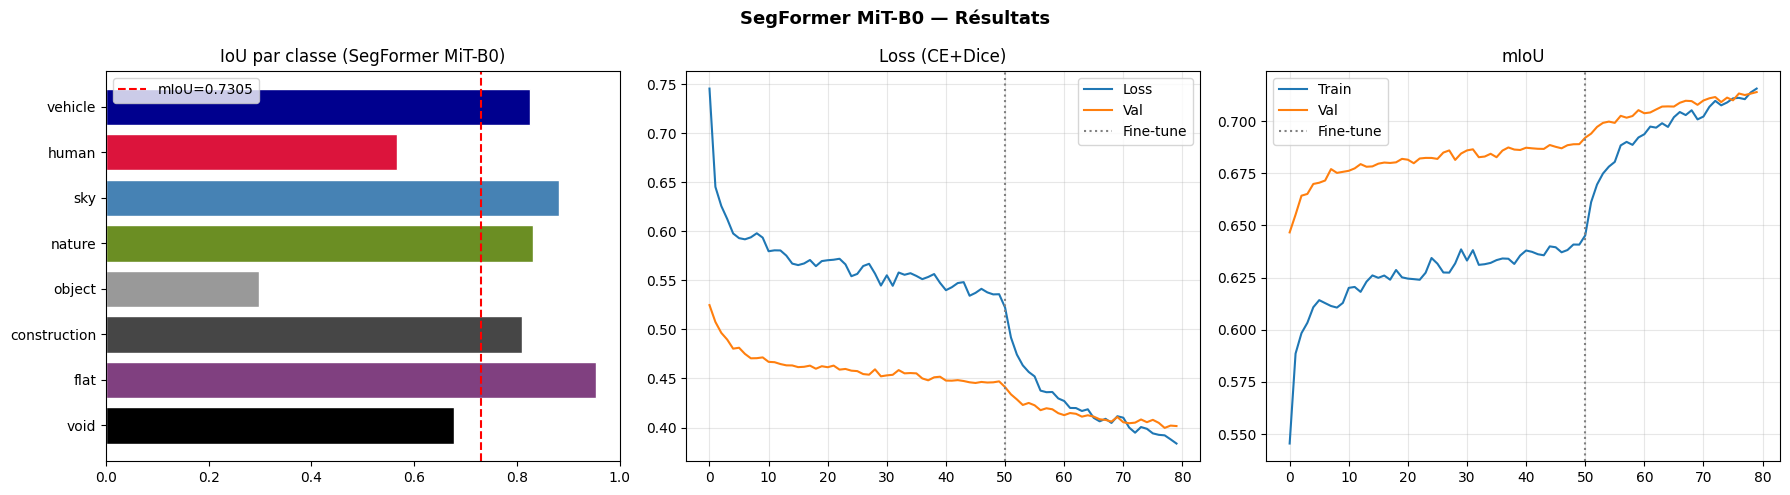

In [ ]:
all_loss  = hist1.history["loss"]  + hist2.history["loss"]
all_vloss = hist1.history["val_loss"] + hist2.history["val_loss"]
all_iou   = hist1.history["mIoU"]  + hist2.history["mIoU"]
all_viou  = hist1.history["val_mIoU"] + hist2.history["val_mIoU"]
ep_split  = len(hist1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]
axes[0].barh(CATEGORY_NAMES, per_class_iou, color=colors, edgecolor="white")
axes[0].axvline(miou_manual, color="red", linestyle="--", label=f"mIoU={miou_manual:.4f}")
axes[0].set_xlim(0,1); axes[0].set_title("IoU par classe (SegFormer MiT-B0)"); axes[0].legend()

axes[1].plot(all_loss,label="Loss"); axes[1].plot(all_vloss, label="Val")
axes[1].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[1].set_title("Loss (CE+Dice)"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(all_iou, label="Train"); axes[2].plot(all_viou, label="Val")
axes[2].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[2].set_title("mIoU"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("SegFormer MiT-B0 — Résultats", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_summary.png"), dpi=120)
plt.show()


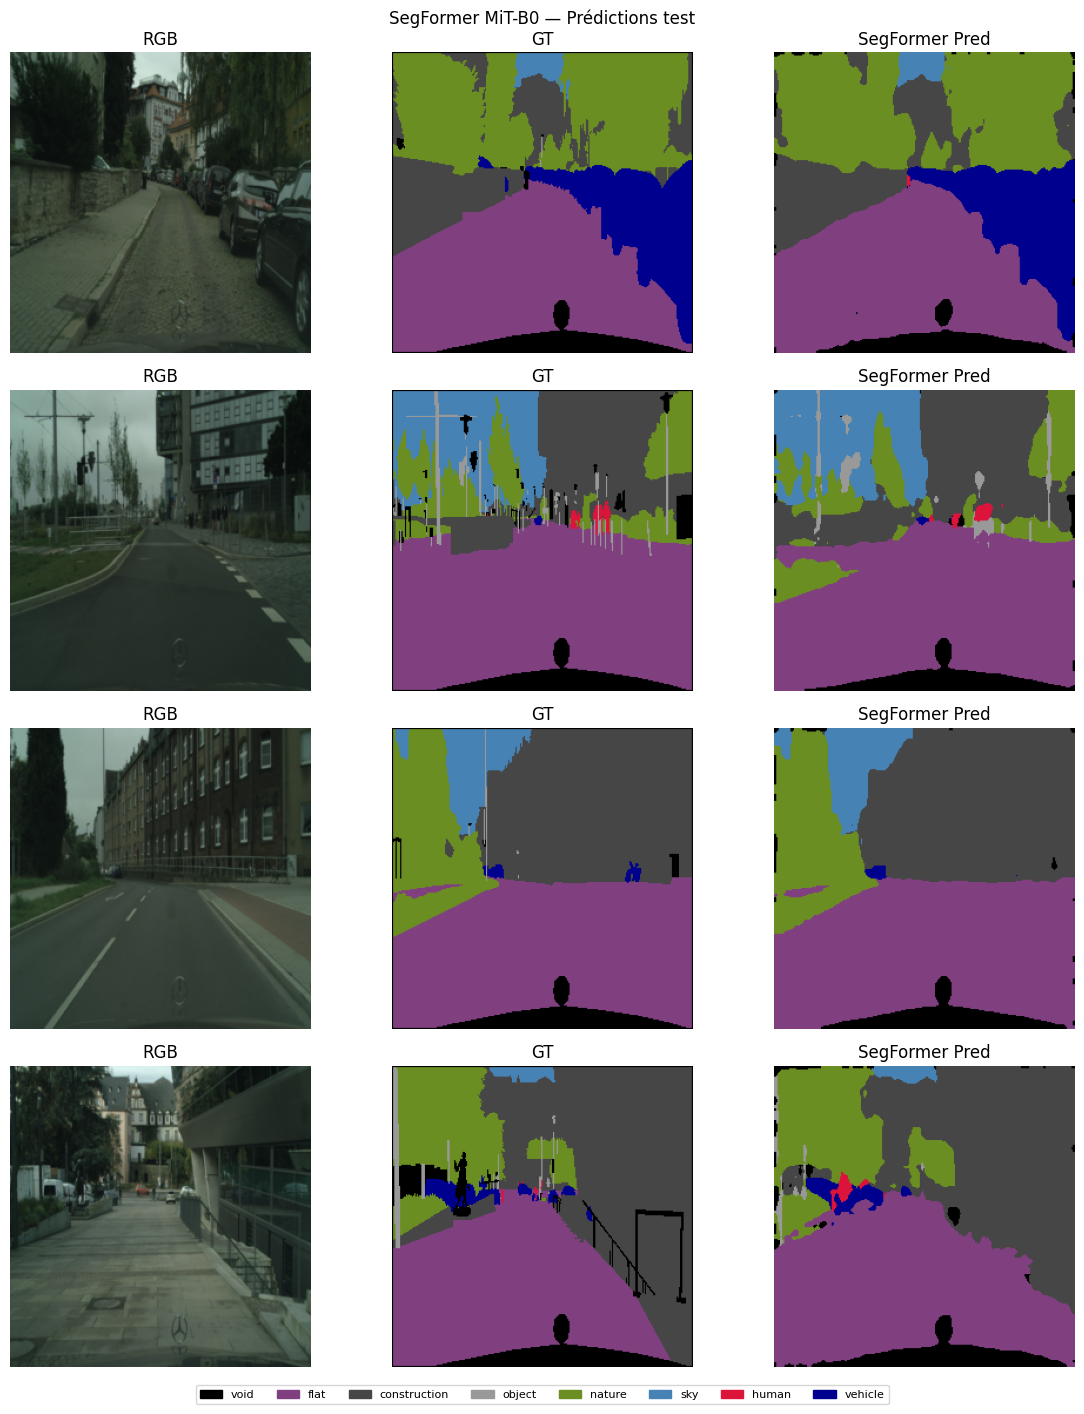

In [ ]:
from PIL import Image as PILImage

def show_predictions(model, seq, n=4):
    X, y   = seq[0]
    X, y   = X[:n], y[:n]
    preds  = np.argmax(model.predict(X, verbose=0), axis=-1)
    fig, axes = plt.subplots(n, 3, figsize=(12, n*3.5))
    for i in range(n):
        arr  = (X[i]*255).astype(np.uint8)
        gt_c = colorize_groups(PILImage.fromarray(y[i,...,0].astype(np.uint8)))
        pr_c = colorize_groups(PILImage.fromarray(preds[i].astype(np.uint8)))
        axes[i,0].imshow(arr);   axes[i,0].set_title("RGB")
        axes[i,1].imshow(gt_c);  axes[i,1].set_title("GT")
        axes[i,2].imshow(pr_c);  axes[i,2].set_title("SegFormer Pred")
        for ax in axes[i]: ax.axis("off")
    patches = [mpatches.Patch(color=[c/255 for c in PALETTE[j]], label=CATEGORY_NAMES[j])
               for j in range(N_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=N_CLASSES,
               bbox_to_anchor=(0.5,-0.02), fontsize=8)
    plt.suptitle("SegFormer MiT-B0 — Prédictions test")
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / f"{RUN_NAME}_preds.png"), dpi=100, bbox_inches="tight")
    plt.show()

show_predictions(model, test_seq)


## Sauvegarde JSON :


In [15]:
combined_history = {
    key: hist1.history.get(key, []) + hist2.history.get(key, [])
    for key in ["loss", "val_loss", "mIoU", "val_mIoU"]
}
results = {
    "run_name"       : RUN_NAME,
    "model"          : "segformer_mitb0",
    "encoder"        : "mit_b0",
    "encoder_preset" : ENCODER_PRESET,
    "framework"      : "tensorflow",
    "input_shape"    : list(SIZE_HW) + [3],
    "best_path"      : str(BEST_PATH),
    "train_time_sec" : float(t_tot),
    "epochs_phase1"  : len(hist1.history["loss"]),
    "epochs_phase2"  : len(hist2.history["loss"]),
    "val_loss"       : float(val_res[0]),
    "val_mIoU"       : float(val_res[1]),
    "test_loss"      : float(test_res[0]),
    "test_mIoU"      : float(test_res[1]),
    "per_class_iou"  : {CATEGORY_NAMES[i]: round(per_class_iou[i], 4) for i in range(N_CLASSES)},
    "history"        : {k: [float(v) for v in vals] for k, vals in combined_history.items()},
}
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"Résultats → {RESULTS_JSON}")
print(f"\n{'='*50}")
print(f" SegFormer MiT-B0")
print(f"{'='*50}")
print(f"  Val  mIoU : {results['val_mIoU']:.4f}")
print(f"  Test mIoU : {results['test_mIoU']:.4f}")
print(f"  Durée     : {t_tot/60:.1f} min")


Résultats → /home/ui/PROJ9/out/experiments/SEGFORMER_MITB0_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42_results.json

 SegFormer MiT-B0
  Val  mIoU : 0.7140
  Test mIoU : 0.7305
  Durée     : 272.7 min
